In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report
)

In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [5]:


def performance_category(mark):
    if mark < 10:
        return 0
    elif mark < 14:
        return 1
    else:
        return 2
y_class = df["G3"].apply(performance_category)

print(y_class.value_counts().sort_index())

G3
0    130
1    165
2    100
Name: count, dtype: int64


In [6]:
features = [
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

X = df[features]

y = df["G3"]
X.head()

,studytime,failures,absences,G1,G2
0,2,0,6,5,6
1,2,0,4,5,5
2,2,3,10,7,8
3,3,0,2,15,14
4,2,0,4,6,10


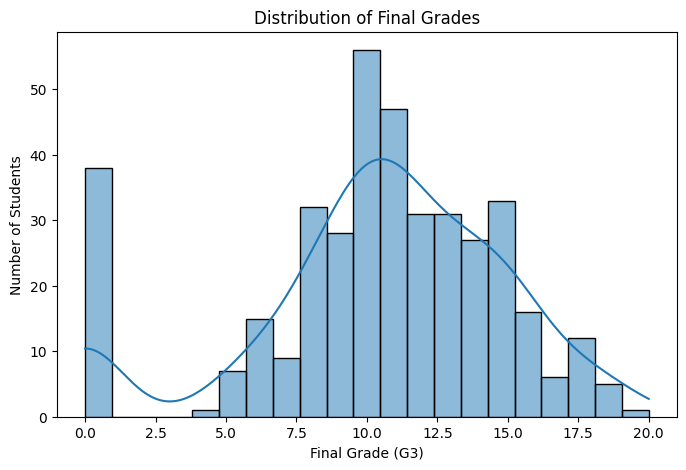

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=21, kde=True)

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")

plt.show()

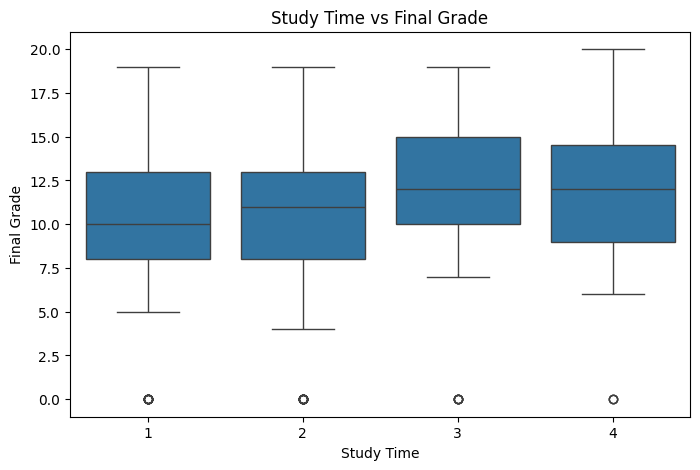

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="studytime",
    y="G3",
    data=df
)

plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")

plt.show()


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# 1. Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv"
)


# 2. Select input features
features = ["studytime", "failures", "absences", "G1", "G2"]

X = df[features]


# 3. Convert G3 marks into 3 categories
def performance_category(mark):
    if mark < 10:
        return 0       # Low
    elif mark < 14:
        return 1       # Medium
    else:
        return 2       # High


y = df["G3"].apply(performance_category)


# Check classes
print("Classes:", y.unique())
print("Class counts:")
print(y.value_counts())


# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 5. Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 6. Multinomial Logistic Regression
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)


# 7. Test the model
y_pred = model.predict(X_test)


# 8. Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# 9. Classification Report
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Low", "Medium", "High"],
        zero_division=0
    )
)


# 10. Give new student input

studytime = 3
failures = 0
absences = 5
G1 = 15
G2 = 16


student_input = pd.DataFrame({
    "studytime": [studytime],
    "failures": [failures],
    "absences": [absences],
    "G1": [G1],
    "G2": [G2]
})


# 11. Scale new input
student_input_scaled = scaler.transform(student_input)


# 12. Predict
prediction = model.predict(student_input_scaled)[0]


# 13. Convert prediction to text
if prediction == 0:
    result = "Low Performance"
elif prediction == 1:
    result = "Medium Performance"
else:
    result = "High Performance"


print("\nPredicted Student Performance:", result)


# 14. Prediction probabilities
probability = model.predict_proba(student_input_scaled)[0]

print("\nPrediction Probabilities:")
print("Low    :", round(probability[0] * 100, 2), "%")
print("Medium :", round(probability[1] * 100, 2), "%")
print("High   :", round(probability[2] * 100, 2), "%")





Classes: [0 1 2]
Class counts:
G3
1    165
0    130
2    100
Name: count, dtype: int64

Accuracy: 82.28 %

Classification Report:
              precision    recall  f1-score   support

         Low       0.81      0.85      0.83        26
      Medium       0.77      0.82      0.79        33
        High       0.94      0.80      0.86        20

    accuracy                           0.82        79
   macro avg       0.84      0.82      0.83        79
weighted avg       0.83      0.82      0.82        79


Predicted Student Performance: High Performance

Prediction Probabilities:
Low    : 0.0 %
Medium : 2.22 %
High   : 97.78 %


In [10]:
# Give student input

studytime = int(input("Enter study time (1-4): "))
failures = int(input("Enter number of failures: "))
absences = int(input("Enter number of absences: "))
G1 = int(input("Enter G1 marks (0-20): "))
G2 = int(input("Enter G2 marks (0-20): "))


# Put input into DataFrame

student = pd.DataFrame({
    "studytime": [studytime],
    "failures": [failures],
    "absences": [absences],
    "G1": [G1],
    "G2": [G2]
})


# Scale the input

student_scaled = scaler.transform(student)


# Predict

prediction = model.predict(student_scaled)[0]


# Convert prediction into category

if prediction == 0:
    result = "Low Performance"
elif prediction == 1:
    result = "Medium Performance"
else:
    result = "High Performance"


print("\nPredicted Performance:", result)

StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Load dataset

df = pd.read_csv(
    "/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv"
)


# 2. Input features

features = ["studytime", "failures", "absences", "G1", "G2"]

X = df[features]

# Target = final grade
y = df["G3"]


# 3. Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 4. Create Polynomial Regression model

model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2)),
    ("regression", LinearRegression())
])


# 5. Train model

model.fit(X_train, y_train)


# 6. Test model

y_pred = model.predict(X_test)


# 7. Evaluate model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Polynomial Regression Results")
print("--------------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))


# 8. Give your own student input

studytime = int(input("\nEnter study time (1-4): "))
failures = int(input("Enter number of failures: "))
absences = int(input("Enter number of absences: "))
G1 = int(input("Enter G1 marks (0-20): "))
G2 = int(input("Enter G2 marks (0-20): "))


# 9. Create input DataFrame

student = pd.DataFrame({
    "studytime": [studytime],
    "failures": [failures],
    "absences": [absences],
    "G1": [G1],
    "G2": [G2]
})


# 10. Predict G3

prediction = model.predict(student)[0]


# 11. Keep prediction between 0 and 20

prediction = max(0, min(20, prediction))


print("\nPredicted Final G3 Marks:", round(prediction, 2))

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 1. Load dataset

df = pd.read_csv(
    "/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv"
)


# 2. Select input features

features = ["studytime", "failures", "absences", "G1", "G2"]

X = df[features]

# Target = final grade
y = df["G3"]


# 3. Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 4. Create Ridge Regression model

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])


# 5. Train model

model.fit(X_train, y_train)


# 6. Test model

y_pred = model.predict(X_test)


# 7. Evaluate model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))


# 8. Give your own student input

studytime = int(input("\nEnter study time (1-4): "))
failures = int(input("Enter number of failures: "))
absences = int(input("Enter number of absences: "))
G1 = int(input("Enter G1 marks (0-20): "))
G2 = int(input("Enter G2 marks (0-20): "))


# 9. Create input DataFrame

student = pd.DataFrame({
    "studytime": [studytime],
    "failures": [failures],
    "absences": [absences],
    "G1": [G1],
    "G2": [G2]
})


# 10. Predict final G3 marks

prediction = model.predict(student)[0]


# 11. Keep prediction between 0 and 20

prediction = max(0, min(20, prediction))


print("\nPredicted Final G3 Marks:", round(prediction, 2))


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# =========================================================
# 1. LOAD DATA
# =========================================================

df = pd.read_csv(
    "/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv"
)


# =========================================================
# 2. FEATURES
# =========================================================

features = ["studytime", "failures", "absences", "G1", "G2"]

X = df[features]
y = df["G3"]


# =========================================================
# 3. MULTINOMIAL LOGISTIC REGRESSION
# =========================================================

# Convert G3 marks into 3 categories

def performance_category(mark):
    if mark < 10:
        return 0
    elif mark < 14:
        return 1
    else:
        return 2


y_class = y.apply(performance_category)


# Split data

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)


# Scaling

scaler_multi = StandardScaler()

X_train_multi = scaler_multi.fit_transform(X_train_multi)
X_test_multi = scaler_multi.transform(X_test_multi)


# Model

model_multi = LogisticRegression(
    max_iter=1000
)

model_multi.fit(X_train_multi, y_train_multi)


# Prediction

y_pred_multi = model_multi.predict(X_test_multi)


# Accuracy

multi_accuracy = accuracy_score(
    y_test_multi,
    y_pred_multi
)


# =========================================================
# 4. POLYNOMIAL REGRESSION
# =========================================================

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


polynomial_model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2)),
    ("regression", LinearRegression())
])


polynomial_model.fit(
    X_train_poly,
    y_train_poly
)


y_pred_poly = polynomial_model.predict(X_test_poly)


poly_mae = mean_absolute_error(
    y_test_poly,
    y_pred_poly
)

poly_rmse = np.sqrt(
    mean_squared_error(
        y_test_poly,
        y_pred_poly
    )
)

poly_r2 = r2_score(
    y_test_poly,
    y_pred_poly
)


# =========================================================
# 5. RIDGE REGRESSION
# =========================================================

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])


ridge_model.fit(
    X_train_poly,
    y_train_poly
)


y_pred_ridge = ridge_model.predict(X_test_poly)


ridge_mae = mean_absolute_error(
    y_test_poly,
    y_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test_poly,
        y_pred_ridge
    )
)

ridge_r2 = r2_score(
    y_test_poly,
    y_pred_ridge
)


# =========================================================
# 6. COMPARISON TABLE
# =========================================================

comparison = pd.DataFrame({

    "Model": [
        "Multinomial Logistic Regression",
        "Polynomial Regression",
        "Ridge Regression"
    ],

    "Task": [
        "Classification",
        "Regression",
        "Regression"
    ],

    "Accuracy": [
        round(multi_accuracy, 3),
        "-",
        "-"
    ],

    "MAE": [
        "-",
        round(poly_mae, 3),
        round(ridge_mae, 3)
    ],

    "RMSE": [
        "-",
        round(poly_rmse, 3),
        round(ridge_rmse, 3)
    ],

    "R2 Score": [
        "-",
        round(poly_r2, 3),
        round(ridge_r2, 3)
    ]
})


print("MODEL COMPARISON")
print("================")

comparison